# 05 — Topology Gallery

Builds, draws, runs, and compares five supply-chain graph shapes on KPIs.
Each graph is drawn with `networkx.multipartite_layout` keyed on echelon level.

**Five topologies**

1. **Linear 3-tier** — `1F → 1S → 1 sink`. Reference shape.
2. **Multi-supplier contention** — `2F → 2S → 2 sinks`. FCFS allocator under contention.
3. **Deep 4-tier (new)** — `factory → DC → shops → sinks` (four echelon levels).
4. **Fan-out fleet** — `llm_world_20` shape: 1 factory, 1 shop, 20 per-product sinks.
5. **Two disconnected sub-graphs** — two independent `F→S→sink` chains in one `Scenario`.

Topologies 1 and 2 reuse existing `scenarios/*.py`. Topologies 3 and 5 are built
by inline `build_*()` helpers (no new `scenarios/*.py` files).
KPI extraction goes through `src/sim/inspect.py`.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import sys
from dataclasses import replace
from datetime import datetime
from pathlib import Path

while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

plt.rcParams['figure.dpi'] = 80
plt.rcParams['savefig.dpi'] = 80
pd.set_option('display.max_columns', None)

In [ ]:
from src.sim.distributions import Constant, Normal, Uniform
from src.sim.graph import EdgeSpec
from src.sim.inspect import node_timeseries_df, per_product_df
from src.sim.node import DemandSinkNode, FactoryNode, IntermediateNode
from src.sim.policy import (
    DefaultDemandSinkPolicy,
    OrderUpToPolicy,
    StaticFactoryPolicy,
)
from src.sim.runner import Runner, build_world
from src.sim.scenario import (
    DisruptionParams,
    ItemLifecycleParams,
    NodeInstance,
    Scenario,
    load_catalog,
)
from src.sim.world import World, world_to_graph

## Shared helpers

Helper to draw a topology and a helper to compute KPIs from `run_log`.

In [3]:
def draw_topology(scenario, title: str, ax=None):
    """Draw the scenario graph with multipartite_layout keyed on echelon level."""
    sim = build_world(scenario)
    levels = sim.levels  # {node_id: int}

    G = nx.DiGraph()
    for ni in scenario.nodes:
        nid = ni.node.id
        G.add_node(nid, layer=levels.get(nid, 0), node_type=type(ni.node).__name__)
    for edge in scenario.edges:
        G.add_edge(edge.supplier_id, edge.buyer_id)

    pos = nx.multipartite_layout(G, subset_key='layer')

    color_map = {
        'FactoryNode': '#4878CF',
        'IntermediateNode': '#6ACC65',
        'DemandSinkNode': '#D65F5F',
    }
    node_colors = [color_map.get(G.nodes[n]['node_type'], 'grey') for n in G.nodes]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    nx.draw(
        G, pos, ax=ax,
        with_labels=True, labels={n: n.split('-', 1)[-1] for n in G.nodes},
        node_color=node_colors, node_size=700, font_size=7,
        arrows=True, arrowsize=15,
    )
    ax.set_title(title, fontsize=10)
    return sim

In [ ]:
def kpis(run_log, scenario) -> dict:
    """Compute headline KPIs from a run_log."""
    df = node_timeseries_df(run_log, scenario)
    first_tick = df['tick'].min()
    last_tick = df['tick'].max()

    cash_start = df[df['tick'] == first_tick]['cash'].sum()
    cash_end = df[df['tick'] == last_tick]['cash'].sum()
    cash_growth = cash_end - cash_start

    # Service level (shop availability): fraction of (tick, carried-product)
    # slots where a shop holds on-hand inventory > 0 — the same service-level
    # proxy used in notebook 06.  Demand sinks place no replenishment orders,
    # so the old `orders_total > 0` on sink nodes was uniformly 0 (meaningless).
    shop_ids = [
        ni.node.id for ni in scenario.nodes
        if isinstance(ni.node, IntermediateNode)
    ]
    available = total = 0
    for sid in shop_ids:
        pp = per_product_df(run_log, scenario, sid)
        if pp.empty:
            continue
        available += int((pp['inventory'] > 0).sum())
        total += len(pp)
    service_level = available / total if total else 0.0

    # Mean inventory across shop nodes.
    shop_df = df[df['node_type'] == 'IntermediateNode']
    mean_inv = shop_df['inventory_total'].mean() if len(shop_df) else 0.0

    n_nodes = scenario.nodes.__len__()
    n_edges = scenario.edges.__len__()

    return {
        'cash_growth': round(cash_growth, 2),
        'service_level': round(float(service_level), 4),
        'mean_shop_inventory': round(float(mean_inv), 2),
        'n_nodes': n_nodes,
        'n_edges': n_edges,
    }

In [5]:
# Shared minimal disruption and lifecycle (stable for comparison).
_STAGES = ['introduction', 'growth', 'maturity', 'decline', 'dead']
NO_DISRUPTION = DisruptionParams(
    event_prob=0.0,
    types=['natural_disaster'],
    regions=['US'],
    severity=Constant(0.0),
    duration=Constant(1),
)
STABLE_LIFECYCLE = ItemLifecycleParams(
    stages=_STAGES,
    init_stage='maturity',
    default_stage_change_probs={s: 0.0 for s in _STAGES},
)
N_STEPS = 90
WORLD_SEED = 42

## Topology 1 — Linear 3-tier chain

`factory-1 → shop-1 → sink-1`. Reference shape; explains echelon levels and tick cascade.

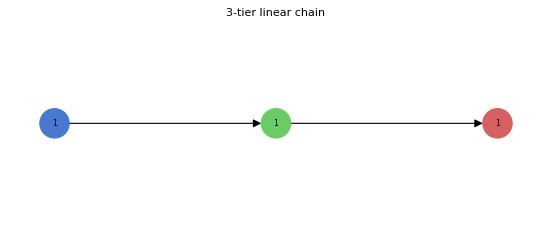

In [6]:
from scenarios.example_chain_three_node import scenario as scenario_chain

fig, ax = plt.subplots(figsize=(7, 3))
sim_chain = draw_topology(scenario_chain, '3-tier linear chain', ax)
fig.tight_layout()
plt.show()

In [7]:
run_log_chain = Runner(scenario_chain).run()
kpis_chain = kpis(run_log_chain, scenario_chain)
print('KPIs — linear chain:', kpis_chain)

KPIs — linear chain: {'cash_growth': np.float64(35800.0), 'service_level': 0.0, 'mean_shop_inventory': 0.06, 'n_nodes': 3, 'n_edges': 2}


## Topology 2 — Multi-supplier contention (2F-2S)

`F_lo + F_hi → S1, S2 → Sink1, Sink2`.
Both shops compete for the same factories. `F_lo` (cheap) depletes under demand bursts,
dropping its `fill_rate_recent` — the central table + FCFS allocator under contention.

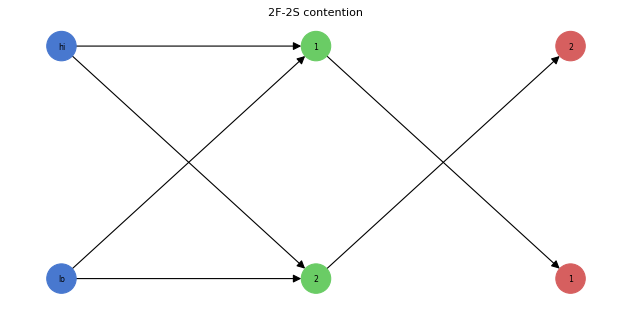

In [8]:
from scenarios.example_two_factories_two_shops import scenario as scenario_2f2s

fig, ax = plt.subplots(figsize=(8, 4))
sim_2f2s = draw_topology(scenario_2f2s, '2F-2S contention', ax)
fig.tight_layout()
plt.show()

In [9]:
run_log_2f2s = Runner(scenario_2f2s).run()
kpis_2f2s = kpis(run_log_2f2s, scenario_2f2s)
print('KPIs — 2F-2S contention:', kpis_2f2s)

KPIs — 2F-2S contention: {'cash_growth': np.float64(71400.0), 'service_level': 0.0, 'mean_shop_inventory': 0.13, 'n_nodes': 6, 'n_edges': 6}


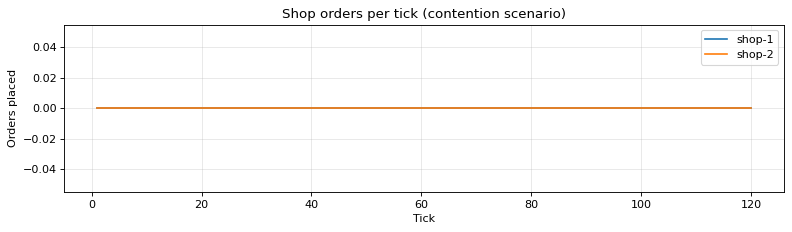

In [10]:
# Inspect fill_rate_recent signal for the cheap factory (f-lo).
# shop nodes use OrderUpToPolicy; check per-tick orders to infer contention.
df_2f2s = node_timeseries_df(run_log_2f2s, scenario_2f2s)
shop_orders = df_2f2s[df_2f2s['node_type'] == 'IntermediateNode'][['tick', 'node_id', 'orders_total']]

fig, ax = plt.subplots(figsize=(10, 3))
for node_id, grp in shop_orders.groupby('node_id'):
    ax.plot(grp['tick'], grp['orders_total'], label=node_id)
ax.set_xlabel('Tick')
ax.set_ylabel('Orders placed')
ax.set_title('Shop orders per tick (contention scenario)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Topology 3 — Deep 4-tier (new)

`factory → DC (warehouse) → shop → sink`.
Four echelon levels; the genuine multi-echelon demonstration no existing scenario shows.
Built by the inline `build_deep_4tier()` helper (no new `scenarios/*.py`).

In [11]:
def build_deep_4tier(n_steps: int = N_STEPS) -> Scenario:
    """factory → DC → shop → sink (4 echelon levels)."""
    catalog = load_catalog([
        {'name': 'Widget', 'category': 'general', 'related_products': [],
         'base_price': 10.0, 'unit_cost': 3.0, 'seasonality': 'all_season'},
    ])
    pid = catalog[0].product_id

    factory = FactoryNode(
        id='4t-factory', region='US', init_seed=1,
        produces_product_id=pid, unit_cost=3.0,
        capacity_per_tick=80, inventory=200, list_price=3.0, cash=0.0,
    )
    factory.policy = StaticFactoryPolicy(capacity_per_tick=80, unit_cost=3.0)

    dc = IntermediateNode(
        id='4t-dc', region='US', init_seed=2,
        carried_products={pid}, capacity=400,
        tags=['warehouse'],
        inventory={pid: 100}, pending={}, list_prices={pid: 5.0},
        min_order_imposed={pid: 0}, cash=10_000.0,
    )
    dc.policy = OrderUpToPolicy(policy_seed=10, cover_horizon_ticks=14)

    shop = IntermediateNode(
        id='4t-shop', region='US', init_seed=3,
        carried_products={pid}, capacity=200,
        tags=['shop'],
        inventory={pid: 50}, pending={}, list_prices={pid: 10.0},
        min_order_imposed={pid: 0}, cash=5_000.0,
    )
    shop.policy = OrderUpToPolicy(policy_seed=20, cover_horizon_ticks=7)

    sink = DemandSinkNode(
        id='4t-sink', region='US', init_seed=4,
        product_id=pid,
        demand_dist=Normal(mean=15, std=3),
        income_rate=300.0, cash=2_000.0,
    )
    sink.policy = DefaultDemandSinkPolicy()

    edges = [
        EdgeSpec(supplier_id='4t-factory', buyer_id='4t-dc', default_lead_time=3),
        EdgeSpec(supplier_id='4t-dc', buyer_id='4t-shop', default_lead_time=2),
        EdgeSpec(supplier_id='4t-shop', buyer_id='4t-sink', default_lead_time=1),
    ]

    return Scenario(
        catalog=catalog,
        market=_make_market(['US'], base_demand=15.0),
        disruption=NO_DISRUPTION,
        item_lifecycle=STABLE_LIFECYCLE,
        stores=[],
        n_steps=n_steps,
        start_date=datetime(2024, 1, 1),
        world_seed=WORLD_SEED,
        nodes=[
            NodeInstance(node=factory, init_seed=1),
            NodeInstance(node=dc, init_seed=2),
            NodeInstance(node=shop, init_seed=3),
            NodeInstance(node=sink, init_seed=4),
        ],
        edges=edges,
    )

from src.sim.scenario import MarketParams

def _make_market(regions, base_demand=10.0):
    return MarketParams(
        cycle_len=365, cycle_amp=0.0,
        init_demand=1.0, init_supply=1.0,
        peak_factor=1.0, off_factor=1.0, season_months={},
        regions=regions, correlation=0.0,
        trend_update_interval=100, min_value=0.5, max_value=2.0,
        stage_multipliers={
            'introduction': 1.0, 'growth': 1.0, 'maturity': 1.0,
            'decline': 1.0, 'dead': 0.0,
        },
        price_elasticity=0.0, promo_multiplier=1.0,
        demand_factor_min=0.1, supply_factor_min=0.01,
        cross_inv_lo=0.3, cross_inv_hi=0.7, cross_factor_range=(0.5, 1.5),
        trend=Constant(1.0), demand_shock=Constant(0.0),
        supply_shock=Constant(0.0), base_demand=Constant(base_demand),
    )

scenario_4tier = build_deep_4tier()
print(f'4-tier scenario: {len(scenario_4tier.nodes)} nodes, {len(scenario_4tier.edges)} edges')

4-tier scenario: 4 nodes, 3 edges


Echelon levels: {'4t-factory': 0, '4t-dc': 1, '4t-shop': 2, '4t-sink': 3}


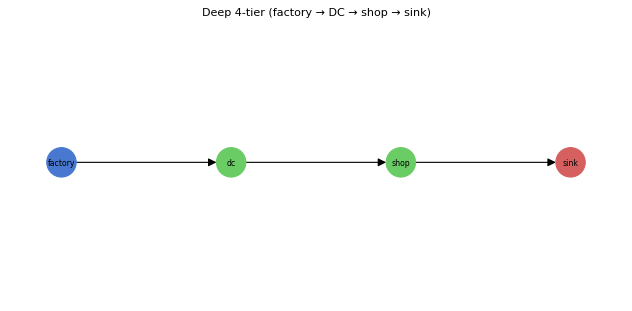

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sim_4tier = draw_topology(scenario_4tier, 'Deep 4-tier (factory → DC → shop → sink)', ax)
print('Echelon levels:', dict(sorted(sim_4tier.levels.items(), key=lambda kv: kv[1])))
fig.tight_layout()
plt.show()

In [13]:
run_log_4tier = Runner(scenario_4tier).run()
kpis_4tier = kpis(run_log_4tier, scenario_4tier)
print('KPIs — deep 4-tier:', kpis_4tier)

KPIs — deep 4-tier: {'cash_growth': np.float64(26700.0), 'service_level': 0.0, 'mean_shop_inventory': 50.33, 'n_nodes': 4, 'n_edges': 3}


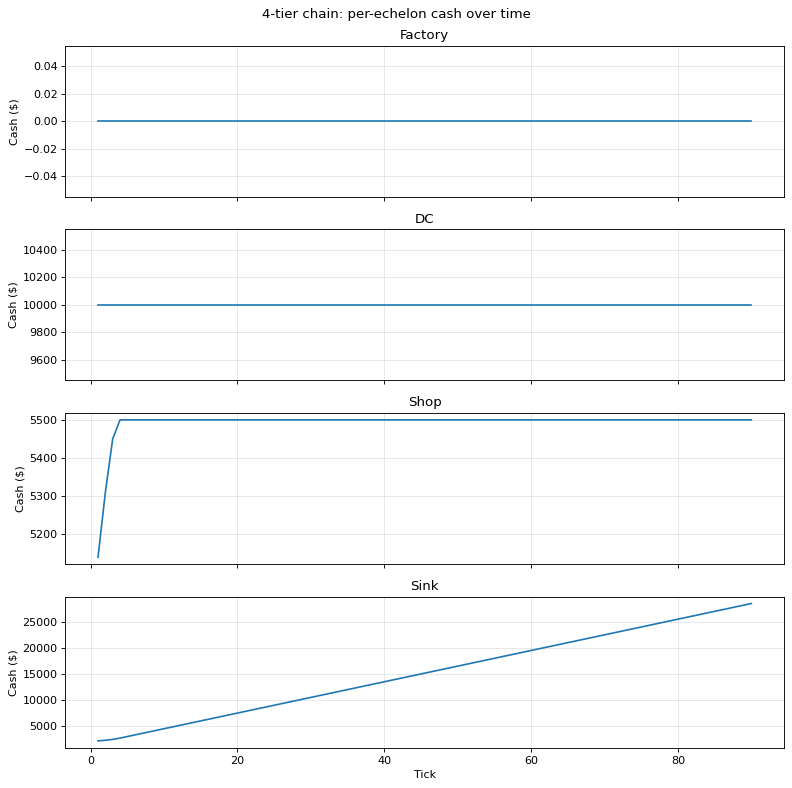

In [14]:
# Show per-tier cash for the 4-tier chain.
df_4t = node_timeseries_df(run_log_4tier, scenario_4tier)
df_4t['level'] = df_4t['node_id'].map(sim_4tier.levels)
level_labels_4t = {0: 'Factory', 1: 'DC', 2: 'Shop', 3: 'Sink'}

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
for ax, (level, grp) in zip(axes, df_4t.groupby('level')):
    ax.plot(grp['tick'], grp['cash'])
    ax.set_ylabel('Cash ($)')
    ax.set_title(level_labels_4t.get(level, f'L{level}'))
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Tick')
fig.suptitle('4-tier chain: per-echelon cash over time', fontsize=12)
fig.tight_layout()
plt.show()

## Topology 4 — Fan-out fleet (`llm_world_20`)

1 factory, 1 shop, 20 per-product demand sinks.
The shape used in all the deep-dive notebooks.

In [15]:
WORLD_PATH = Path('data/worlds/fashion_retail_20/world.json')
world = World.from_json(WORLD_PATH)
_base = next(iter(world.store_templates.values()))
template = replace(
    _base, id='flagship_20_0', capacity=400, init_balance=500_000.0,
    init_active_count=10, init_freshness='baseline', init_stock_pct=0.0,
    order_fee=10.0,
)
world_fleet = replace(world, store_templates={'flagship_20_0': template})
topo_fleet = world_to_graph(world_fleet, sink_density=1.0)

shop_idx = 0
for ni in topo_fleet['node_instances']:
    node = ni.node
    if isinstance(node, FactoryNode):
        ni.policy = StaticFactoryPolicy(
            capacity_per_tick=node.capacity_per_tick, unit_cost=node.unit_cost
        )
    elif isinstance(node, IntermediateNode):
        ni.policy = OrderUpToPolicy(policy_seed=1000 + shop_idx, cover_horizon_ticks=30)
        shop_idx += 1
    elif isinstance(node, DemandSinkNode):
        ni.policy = DefaultDemandSinkPolicy()

scenario_fleet = Scenario.from_world(
    world_fleet,
    disruption=NO_DISRUPTION,
    item_lifecycle=STABLE_LIFECYCLE,
    nodes=topo_fleet['node_instances'],
    edges=topo_fleet['edges'],
    n_steps=N_STEPS,
    start_date=datetime(2024, 1, 1),
    world_seed=WORLD_SEED,
)
print(f'Fleet: {len(scenario_fleet.nodes)} nodes, {len(scenario_fleet.edges)} edges')

Fleet: 22 nodes, 21 edges


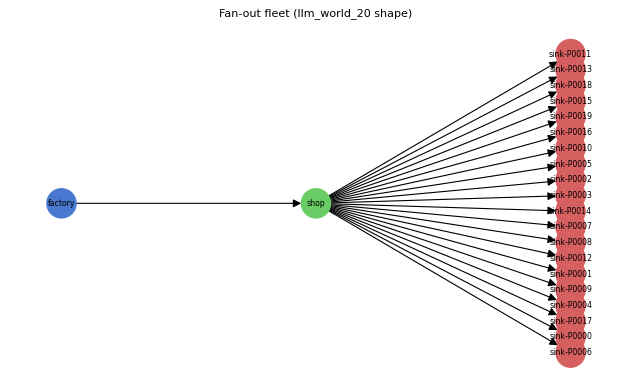

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
sim_fleet = draw_topology(scenario_fleet, 'Fan-out fleet (llm_world_20 shape)', ax)
fig.tight_layout()
plt.show()

In [17]:
run_log_fleet = Runner(scenario_fleet).run()
kpis_fleet = kpis(run_log_fleet, scenario_fleet)
print('KPIs — fan-out fleet:', kpis_fleet)

KPIs — fan-out fleet: {'cash_growth': np.float64(356000.0), 'service_level': 0.0, 'mean_shop_inventory': 28.89, 'n_nodes': 22, 'n_edges': 21}


## Topology 5 — Two disconnected sub-graphs

Two independent `F→S→sink` chains in one `Scenario` sharing no nodes.
Valid because `build_graph` rejects cycles and same-level supplier links,
but disconnected components are permitted.

Built by the inline `build_two_disconnected()` helper.

In [18]:
def build_two_disconnected(n_steps: int = N_STEPS) -> Scenario:
    """Two independent F→S→sink chains in one Scenario."""
    catalog = load_catalog([
        {'name': 'Alpha', 'category': 'general', 'related_products': [],
         'base_price': 8.0, 'unit_cost': 3.0, 'seasonality': 'all_season'},
        {'name': 'Beta', 'category': 'general', 'related_products': [],
         'base_price': 12.0, 'unit_cost': 5.0, 'seasonality': 'all_season'},
    ])
    pid_a, pid_b = catalog[0].product_id, catalog[1].product_id

    def chain(suffix, pid, unit_cost, list_price_shop, demand_mean, seed_base):
        fac = FactoryNode(
            id=f'disc-factory-{suffix}', region='US', init_seed=seed_base,
            produces_product_id=pid, unit_cost=unit_cost,
            capacity_per_tick=60, inventory=150, list_price=unit_cost, cash=0.0,
        )
        fac.policy = StaticFactoryPolicy(capacity_per_tick=60, unit_cost=unit_cost)
        shop = IntermediateNode(
            id=f'disc-shop-{suffix}', region='US', init_seed=seed_base + 1,
            carried_products={pid}, capacity=300, tags=['shop'],
            inventory={pid: 40}, pending={}, list_prices={pid: list_price_shop},
            min_order_imposed={pid: 0}, cash=8_000.0,
        )
        shop.policy = OrderUpToPolicy(policy_seed=seed_base + 1, cover_horizon_ticks=14)
        sink = DemandSinkNode(
            id=f'disc-sink-{suffix}', region='US', init_seed=seed_base + 2,
            product_id=pid, demand_dist=Normal(mean=demand_mean, std=2),
            income_rate=demand_mean * list_price_shop, cash=2_000.0,
        )
        sink.policy = DefaultDemandSinkPolicy()
        edges = [
            EdgeSpec(supplier_id=fac.id, buyer_id=shop.id, default_lead_time=2),
            EdgeSpec(supplier_id=shop.id, buyer_id=sink.id, default_lead_time=1),
        ]
        nodes = [
            NodeInstance(node=fac, init_seed=seed_base),
            NodeInstance(node=shop, init_seed=seed_base + 1),
            NodeInstance(node=sink, init_seed=seed_base + 2),
        ]
        return nodes, edges

    nodes_a, edges_a = chain('A', pid_a, 3.0, 8.0, 12, seed_base=1)
    nodes_b, edges_b = chain('B', pid_b, 5.0, 12.0, 8, seed_base=10)

    return Scenario(
        catalog=catalog,
        market=_make_market(['US'], base_demand=10.0),
        disruption=NO_DISRUPTION,
        item_lifecycle=STABLE_LIFECYCLE,
        stores=[],
        n_steps=n_steps,
        start_date=datetime(2024, 1, 1),
        world_seed=WORLD_SEED,
        nodes=nodes_a + nodes_b,
        edges=edges_a + edges_b,
    )

scenario_disconnected = build_two_disconnected()
print(f'Disconnected: {len(scenario_disconnected.nodes)} nodes, '
      f'{len(scenario_disconnected.edges)} edges')

Disconnected: 6 nodes, 4 edges


Levels: {'disc-factory-A': 0, 'disc-factory-B': 0, 'disc-shop-A': 1, 'disc-shop-B': 1, 'disc-sink-A': 2, 'disc-sink-B': 2}


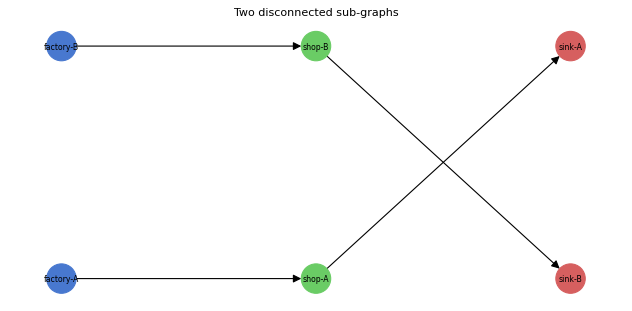

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
sim_disc = draw_topology(scenario_disconnected, 'Two disconnected sub-graphs', ax)
print('Levels:', dict(sorted(sim_disc.levels.items(), key=lambda kv: kv[1])))
fig.tight_layout()
plt.show()

In [20]:
run_log_disc = Runner(scenario_disconnected).run()
kpis_disc = kpis(run_log_disc, scenario_disconnected)
print('KPIs — disconnected:', kpis_disc)

KPIs — disconnected: {'cash_growth': np.float64(17088.0), 'service_level': 0.0, 'mean_shop_inventory': 0.79, 'n_nodes': 6, 'n_edges': 4}


## KPI comparison across all five topologies

Side-by-side bar chart of cash growth, service level, and mean shop inventory.

In [21]:
comparison = pd.DataFrame({
    '3-tier linear': kpis_chain,
    '2F-2S contention': kpis_2f2s,
    '4-tier deep': kpis_4tier,
    'Fan-out fleet': kpis_fleet,
    'Disconnected': kpis_disc,
}).T
comparison

,cash_growth,service_level,mean_shop_inventory,n_nodes,n_edges
3-tier linear,35800.0,0.0,0.06,3.0,2.0
2F-2S contention,71400.0,0.0,0.13,6.0,6.0
4-tier deep,26700.0,0.0,50.33,4.0,3.0
Fan-out fleet,356000.0,0.0,28.89,22.0,21.0
Disconnected,17088.0,0.0,0.79,6.0,4.0


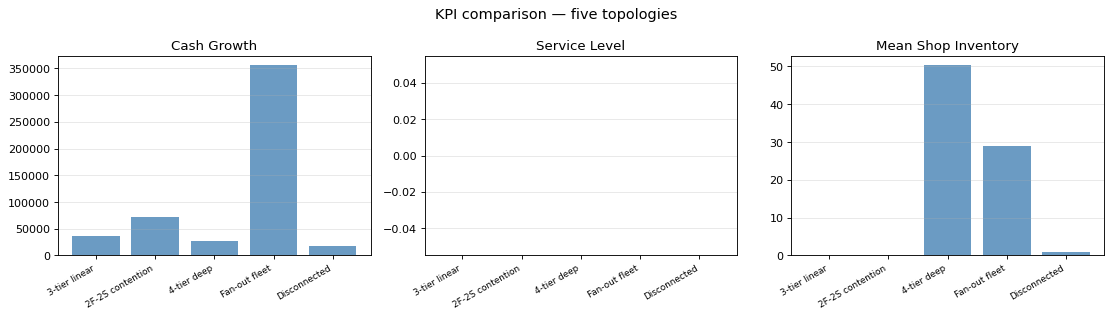

In [22]:
metrics = ['cash_growth', 'service_level', 'mean_shop_inventory']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, metrics):
    vals = comparison[metric]
    ax.bar(range(len(vals)), vals, color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    ax.set_title(metric.replace('_', ' ').title())
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('KPI comparison — five topologies', fontsize=13)
fig.tight_layout()
plt.show()